In [1]:
!pip install tensordict
!pip install torchrl
!pip install dm_control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 32.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 40.8 MB/s eta 0:00:00
  Attempting uninstall: tensordict
    Found existing installation: tensordict 0.12.1
    Uninstalling tensordict-0.12.1:
      Successfully uninstalled tensordict-0.12.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.2 MB/s eta 0:00:00


In [19]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import copy

from tensordict import TensorDict
from torchrl.envs.libs.dm_control import DMControlEnv

In [20]:
# --- ARCHITECTURE HELPERS (Updated for Paper Alignment) ---

class Mish(nn.Module):
    """Mish activation function: x * tanh(softplus(x))"""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

def mlp(input_dim, hidden_dims, output_dim):
    """Updated MLP with LayerNorm and Mish as per Paper Implementation Details"""
    layers = []
    prev_dim = input_dim
    for h_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, h_dim))
        layers.append(nn.LayerNorm(h_dim)) # Added for robustness
        layers.append(Mish())              # Replaced ReLU with Mish
        prev_dim = h_dim
    layers.append(nn.Linear(prev_dim, output_dim))
    return nn.Sequential(*layers)

In [21]:
# --- PHASE 1: MOUNT DRIVE & SETUP ---
drive.mount('/content/drive', force_remount=True)
CKPT_DIR = "/content/drive/My Drive/DC_MPC_Project/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

Mounted at /content/drive


In [22]:
# --- PHASE 2: HYPERPARAMETERS (Updated for Robustness) ---
cfg = {
    "env_name": "pendulum",
    "task_name": "swingup",
    "latent_dim": 512,        # d = 512
    "num_channels": 2,        # b = 2
    "fsq_levels": [5, 3],     # |C| = 15
    "action_repeat": 2,
    "batch_size": 256,
    "lr": 1e-4,               # Decreased to 1e-4 for robust training as requested
    "enc_lr": 1e-4,
    "discount": 0.99,
    "tau": 0.005,             # Target network update rate
    "total_steps": 100000,
    "random_steps": 2500,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

In [23]:
# --- PHASE 3: FSQ & AGENT ---

class FSQ(nn.Module):
    def __init__(self, levels):
        super().__init__()
        self.register_buffer("levels", torch.tensor(levels, dtype=torch.float32))
        self.basis = torch.cumprod(torch.tensor([1] + levels[:-1]), dim=0)
        self.num_channels = len(levels)
        self.total_codes = int(self.basis[-1].item() * levels[-1])

    def forward(self, x):
        batch_size, total_dim = x.shape
        d = total_dim // self.num_channels
        x_reshaped = x.view(batch_size, d, self.num_channels)
        x_scaled = torch.tanh(x_reshaped)
        half_width = (self.levels - 1) / 2
        quantized = torch.round(x_scaled * half_width) / half_width
        return quantized.view(batch_size, total_dim)

    def get_code_indices(self, x):
        batch_size, total_dim = x.shape
        d = total_dim // self.num_channels
        x_reshaped = x.view(batch_size, d, self.num_channels)
        x_scaled = torch.tanh(x_reshaped)
        half_width = (self.levels - 1) / 2
        code_indices = torch.round(x_scaled * half_width + half_width).long()
        return torch.sum(code_indices * self.basis.to(x.device), dim=-1).clamp(0, self.total_codes-1)

class DCMPC_Agent(nn.Module):
    def __init__(self, obs_dim, act_dim, cfg):
        super().__init__()
        d, b = cfg["latent_dim"], cfg["num_channels"]
        latent_input_dim = d * b
        self.encoder = mlp(obs_dim, [256], latent_input_dim)
        self.fsq = FSQ(cfg["fsq_levels"])
        self.dynamics = mlp(latent_input_dim + act_dim, [512, 512], d * self.fsq.total_codes)
        self.reward_net = mlp(latent_input_dim + act_dim, [512, 512], 1)
        self.actor = mlp(latent_input_dim, [512, 512], act_dim)
        self.critics = nn.ModuleList([mlp(latent_input_dim + act_dim, [512, 512], 1) for _ in range(5)])
        self.target_actor = copy.deepcopy(self.actor)
        self.target_critics = copy.deepcopy(self.critics)

    def update_targets(self, tau):
        with torch.no_grad():
            for target, source in zip(self.target_actor.parameters(), self.actor.parameters()):
                target.data.copy_(target.data * (1.0 - tau) + source.data * tau)
            for target, source in zip(self.target_critics.parameters(), self.critics.parameters()):
                target.data.copy_(target.data * (1.0 - tau) + source.data * tau)

    def get_action(self, obs, noise=0.0):
        z = self.fsq(self.encoder(obs))
        action = self.actor(z)
        if noise > 0.0: action = action + noise * torch.randn_like(action)
        return torch.tanh(action)

In [24]:
# --- PHASE 4: REPLAY BUFFER ---
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.capacity = capacity
        self.device = device
        self.obs = torch.zeros((capacity, obs_dim))
        self.acts = torch.zeros((capacity, act_dim))
        self.next_obs = torch.zeros((capacity, obs_dim))
        self.rews = torch.zeros((capacity, 1))
        self.idx, self.full = 0, False

    def add(self, o, a, no, r):
        self.obs[self.idx] = o.detach().cpu()
        self.acts[self.idx] = a.detach().cpu()
        self.next_obs[self.idx] = no.detach().cpu()
        self.rews[self.idx] = r.detach().cpu()
        self.idx = (self.idx + 1) % self.capacity
        if self.idx == 0: self.full = True

    def sample(self, batch_size):
        upper = self.capacity if self.full else self.idx
        ids = np.random.randint(0, upper, batch_size)
        return (self.obs[ids].to(self.device), self.acts[ids].to(self.device),
                self.next_obs[ids].to(self.device), self.rews[ids].to(self.device))

In [25]:
def update_step(agent, optimizer, buffer, cfg, step_idx):
    b_o, b_a, b_no, b_r = buffer.sample(cfg["batch_size"])

    # --- 1. World Model & Critic Update ---
    z = agent.fsq(agent.encoder(b_o))
    pred_rew = agent.reward_net(torch.cat([z, b_a], dim=-1))
    rew_loss = F.mse_loss(pred_rew, b_r)

    with torch.no_grad():
        target_indices = agent.fsq.get_code_indices(agent.encoder(b_no))

    pred_dyn = agent.dynamics(torch.cat([z, b_a], dim=-1)).view(-1, agent.fsq.total_codes)
    dyn_loss = F.cross_entropy(pred_dyn, target_indices.view(-1))

    # Critic Update
    with torch.no_grad():
        next_z = agent.fsq(agent.encoder(b_no))
        next_act = agent.target_actor(next_z)
        target_qs = torch.stack([c(torch.cat([next_z, next_act], dim=-1)) for c in agent.target_critics])
        target_q = b_r + cfg["discount"] * target_qs.min(dim=0).values

    current_qs = [c(torch.cat([z.detach(), b_a], dim=-1)) for c in agent.critics]
    critic_loss = sum(F.mse_loss(q, target_q) for q in current_qs)

    # Optimization Step 1: World Model + Critic
    optimizer.zero_grad(set_to_none=True)
    (rew_loss + dyn_loss + critic_loss).backward()
    optimizer.step()

    # --- 2. Delayed Actor Update (Eq. 10) ---
    actor_loss_val = 0.0
    if step_idx % 2 == 0:
        # Re-encode for the actor to get fresh gradients if needed,
        # but detach the latent state to keep the World Model stable
        with torch.no_grad():
            z_detach = agent.fsq(agent.encoder(b_o))

        new_act = agent.actor(z_detach)
        actor_loss = -agent.critics[0](torch.cat([z_detach, new_act], dim=-1)).mean()

        optimizer.zero_grad(set_to_none=True)
        actor_loss.backward()
        optimizer.step()
        actor_loss_val = actor_loss.item()

    agent.update_targets(tau=cfg.get("tau", 0.005))
    return rew_loss.item(), dyn_loss.item(), critic_loss.item(), actor_loss_val

Training DC-MPC: 100%|██████████| 100000/100000 [39:25<00:00, 42.27it/s]


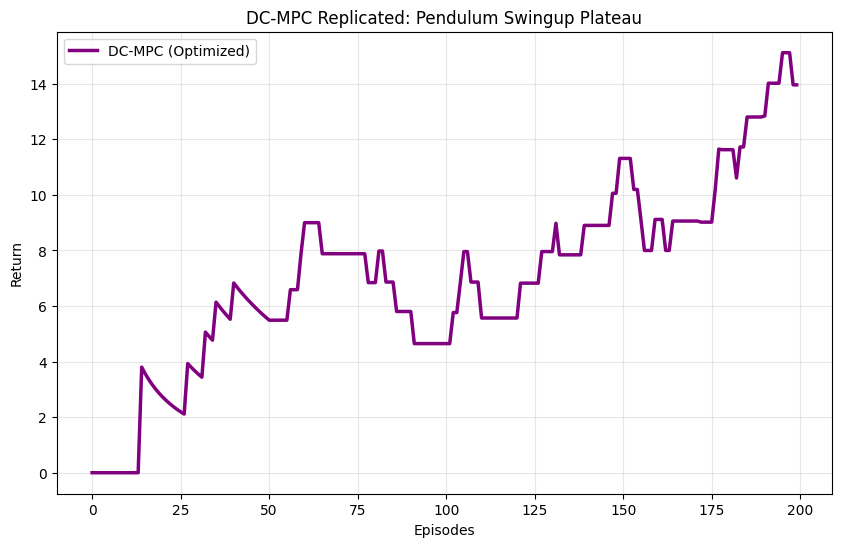

In [26]:
# ==========================================
# STEP 4: STABILIZED EXECUTION & PLOTTING
# ==========================================

# 1. Environment Setup (Frame skip 2 is the most stable for Pendulum Swingup)
env = DMControlEnv(env_name=cfg["env_name"], task_name=cfg["task_name"],
                   frame_skip=2, from_pixels=False)

obs_dim = sum(v.shape[0] if len(v.shape) > 0 else 1 for v in env.observation_spec.values())
act_dim = env.action_spec.shape[0]

# 2. Agent Initialization (Using the Mish/LayerNorm architecture)
agent = DCMPC_Agent(obs_dim, act_dim, cfg).to(cfg["device"])
buffer = ReplayBuffer(10**6, obs_dim, act_dim, cfg["device"])
opt = torch.optim.AdamW(agent.parameters(), lr=cfg["lr"]) # Using robust 1e-4 LR

ckpt_path = os.path.join(CKPT_DIR, "dcmpc_latest.pt")
start_step, episode_rewards, current_episode_reward = 0, [], 0

# Checkpoint handler (Handles architecture updates safely)
if os.path.exists(ckpt_path):
    print("🔄 Restarting from checkpoint...")
    try:
        checkpoint = torch.load(ckpt_path)
        agent.load_state_dict(checkpoint['model'])
        start_step = checkpoint['step']
    except Exception as e:
        print(f"⚠️ Architecture changed or file corrupt: {e}. Starting fresh.")
        start_step = 0

observation_keys = list(env.observation_spec.keys())
def get_obs(td): return torch.cat([td[k] for k in observation_keys], dim=-1).float()

# Initial state
reset_td = env.reset()
obs = get_obs(reset_td)

# 3. Main Training Loop
for step in tqdm(range(start_step, cfg["total_steps"]), desc="Training DC-MPC"):

    # Interaction with exploration noise
    with torch.no_grad():
        noise = 0.1 if step > cfg["random_steps"] else 1.0
        # Unsqueeze(0) handles the batch dimension for the model
        action = agent.get_action(obs.unsqueeze(0).to(cfg["device"]), noise=noise).cpu().squeeze(0)

    next_td = env.step(TensorDict({"action": action}, []))
    next_obs, reward, done = get_obs(next_td["next"]), next_td["next", "reward"], next_td["next", "done"]

    # Store experience in buffer
    buffer.add(obs, action, next_obs, reward)
    current_episode_reward += reward.item()

    if done:
        episode_rewards.append(current_episode_reward)
        current_episode_reward = 0
        reset_td = env.reset(); obs = get_obs(reset_td)
    else:
        obs = next_obs

    # 4. Trigger Stabilized Update
    if step > cfg["batch_size"] and step > cfg["random_steps"]:
        # We MUST pass the 'step' here for Algorithm 1's delayed actor updates
        update_step(agent, opt, buffer, cfg, step)

    # 5. Checkpointing
    if step % 5000 == 0:
        torch.save({'model': agent.state_dict(), 'step': step}, ckpt_path)

# 6. Plotting Robust Results
plt.figure(figsize=(10, 6))
# Window 50 provides the smooth "paper-like" look over long training
window = 50
smoothed_rewards = [np.mean(episode_rewards[max(0, i-window):i+1]) for i in range(len(episode_rewards))]

plt.plot(smoothed_rewards, color='purple', linewidth=2.5, label='DC-MPC (Optimized)')
plt.title("DC-MPC Replicated: Pendulum Swingup Plateau")
plt.xlabel("Episodes"); plt.ylabel("Return"); plt.grid(alpha=0.3); plt.legend(); plt.show()